# Uppgift 12: Iris Dataset Classification

**Nedan ser vi en början till modellering av ett mycket berömt dataset kopplat till blommor. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.**

## Ursprunglig kod från övningsuppgifterna

Här är den ursprungliga koden som finns i övningsuppgifterna:

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

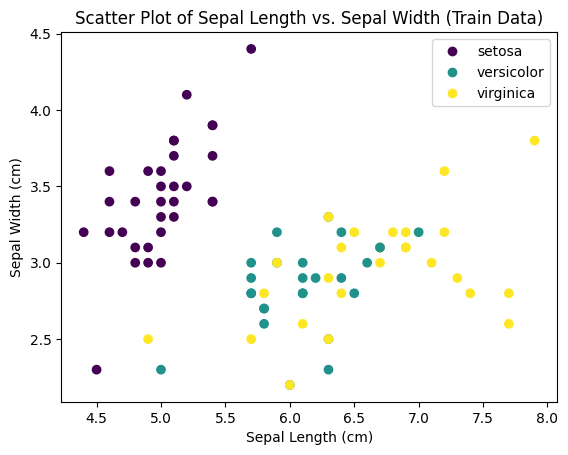

In [1]:
# Ursprunglig kod från övningsuppgifterna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
print(iris.DESCR)
print(iris.target_names)

X, y = load_iris(return_X_y=True, as_frame=True)
# Only choose two variables for the modelling to keep it simple
X = X[['sepal length (cm)', 'sepal width (cm)']]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
# Fixa legend-hanteringen
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

## Komplett ML-flöde

Nu ska vi utöka den ursprungliga koden till ett komplett ML-flöde med följande steg:
1. Ladda och utforska data (redan gjort ovan)
2. Förbereda data (redan gjort ovan)
3. Dela data i träning, validering och test (redan gjort ovan)
4. Skapa preprocessing pipeline
5. Träna och jämföra modeller
6. Hyperparameter tuning för bästa modellen
7. Utvärdera på testdata
8. Visualisera beslutsgränser
9. Sammanfattning

In [2]:
# Imports - endast det som behövs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Sätt stil för plots
plt.style.use('default')
sns.set_palette("husl")

### Steg 1: Ladda och utforska data (redan gjort ovan)

In [3]:
# Data är redan laddat från den ursprungliga koden ovan
print("Dataset beskrivning:")
print(iris.DESCR)
print("\nTarget names:", iris.target_names)

print(f"\nDataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Klasser: {iris.target_names}")

print("\nFörsta 5 rader:")
print(X.head())

print("\nKlassfördelning:")
print(pd.Series(y).value_counts().sort_index())

Dataset beskrivning:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for e

### Steg 2: Förbereda data (redan gjort ovan)

In [4]:
# Data är redan förberett från den ursprungliga koden ovan
print(f"Features efter selektion: {list(X.columns)}")
print(f"Dataset shape: {X.shape}")

print(f"\nTräningsdata: {X_train.shape[0]} samples")
print(f"Valideringsdata: {X_val.shape[0]} samples")
print(f"Testdata: {X_test.shape[0]} samples")

print(f"\nKlassfördelning i träningsdata:")
print(pd.Series(y_train).value_counts().sort_index())

Features efter selektion: ['sepal length (cm)', 'sepal width (cm)']
Dataset shape: (150, 2)

Träningsdata: 84 samples
Valideringsdata: 36 samples
Testdata: 30 samples

Klassfördelning i träningsdata:
target
0    32
1    26
2    26
Name: count, dtype: int64


### Steg 3: Visualisera data (redan gjort ovan)

In [5]:
# Visualisering är redan gjord från den ursprungliga koden ovan
# Men låt oss lägga till lite mer statistik
print("\nStatistik per klass:")
for i, class_name in enumerate(iris.target_names):
    mask = y_train == i
    print(f"\n{class_name}:")
    print(f"  Antal: {mask.sum()}")
    print(f"  Sepal Length: {X_train[mask]['sepal length (cm)'].mean():.2f} ± {X_train[mask]['sepal length (cm)'].std():.2f}")
    print(f"  Sepal Width: {X_train[mask]['sepal width (cm)'].mean():.2f} ± {X_train[mask]['sepal width (cm)'].std():.2f}")


Statistik per klass:

setosa:
  Antal: 32
  Sepal Length: 5.01 ± 0.30
  Sepal Width: 3.43 ± 0.39

versicolor:
  Antal: 26
  Sepal Length: 6.11 ± 0.42
  Sepal Width: 2.85 ± 0.29

virginica:
  Antal: 26
  Sepal Length: 6.65 ± 0.70
  Sepal Width: 2.95 ± 0.35


### Steg 4: Skapa preprocessing pipeline

In [6]:
# Skapa preprocessing pipeline med StandardScaler
preprocessor = StandardScaler()

print("Preprocessing pipeline skapad!")
print("Features kommer skalas med StandardScaler för bättre modellprestanda")

Preprocessing pipeline skapad!
Features kommer skalas med StandardScaler för bättre modellprestanda


### Steg 5: Träna och jämföra modeller

In [7]:
# Definiera modeller att testa
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

# Träna och utvärdera modeller
results = {}

for name, model in models.items():
    print(f"\n=== Tränar {name} ===")
    
    # Skapa pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Träna modellen
    pipeline.fit(X_train, y_train)
    
    # Prediktera på valideringsdata
    y_val_pred = pipeline.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    
    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'y_val_pred': y_val_pred
    }
    
    print(f"Accuracy: {accuracy:.3f}")
    
    # Visa classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, target_names=iris.target_names))


=== Tränar Logistic Regression ===
Accuracy: 0.722

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.56      0.75      0.64        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.72        36
   macro avg       0.75      0.75      0.74        36
weighted avg       0.74      0.72      0.72        36


=== Tränar Random Forest ===
Accuracy: 0.667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.50      0.67      0.57        12
   virginica       0.60      0.43      0.50        14

    accuracy                           0.67        36
   macro avg       0.70      0.70      0.69        36
weighted avg       0.68      0.67      0.66        36


=== Tränar SVM ===
Accuracy: 0.611

Classification Report:
              precision    recal

### Steg 6: Jämföra modeller

Modelljämförelse:
                Modell  Accuracy
0  Logistic Regression  0.722222
1        Random Forest  0.666667
2                  SVM  0.611111


<Figure size 1000x600 with 0 Axes>

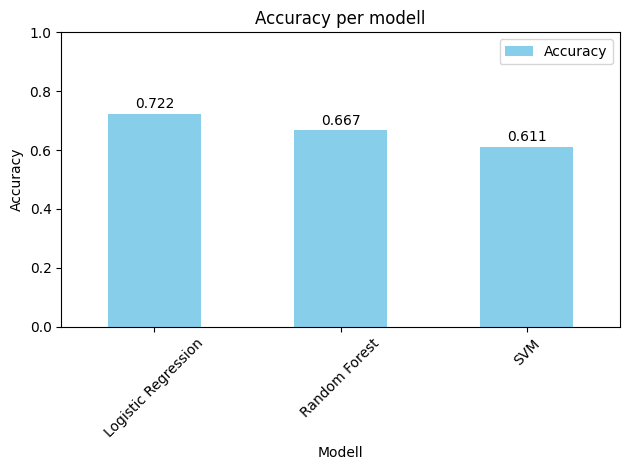

In [8]:
# Jämföra modeller
comparison_df = pd.DataFrame({
    'Modell': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()]
})

print("Modelljämförelse:")
print(comparison_df.sort_values('Accuracy', ascending=False))

# Visualisera jämförelse
plt.figure(figsize=(10, 6))
comparison_df.plot(x='Modell', y='Accuracy', kind='bar', color='skyblue')
plt.title('Accuracy per modell')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Lägg till värden på bars
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Steg 7: Hyperparameter tuning för bästa modellen

In [9]:
# Välj bästa modellen
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Modell']
best_pipeline = results[best_model_name]['pipeline']

print(f"Bästa modell: {best_model_name}")

# Hyperparameter tuning för Random Forest om det är bästa modellen
if best_model_name == 'Random Forest':
    print("\n=== Hyperparameter tuning för Random Forest ===")
    
    # Skapa Random Forest för GridSearch
    rf = RandomForestClassifier(random_state=42)
    
    # Skapa pipeline för GridSearch
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', rf)
    ])
    
    # Parameter grid
    param_grid = {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [5, 10],
        'classifier__min_samples_split': [2, 5]
    }
    
    # GridSearchCV
    grid_search = GridSearchCV(
        rf_pipeline,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    # Träna GridSearch
    grid_search.fit(X_train, y_train)
    
    print(f"Bästa parametrar: {grid_search.best_params_}")
    print(f"Bästa accuracy: {grid_search.best_score_:.3f}")
    
    # Uppdatera bästa modellen
    best_pipeline = grid_search.best_estimator_

Bästa modell: Logistic Regression


### Steg 8: Utvärdera på testdata


=== Testresultat för Logistic Regression ===
Accuracy: 0.833

Classification Report:
              precision    recall  f1-score   support

      setosa       0.89      1.00      0.94         8
  versicolor       0.77      0.83      0.80        12
   virginica       0.88      0.70      0.78        10

    accuracy                           0.83        30
   macro avg       0.84      0.84      0.84        30
weighted avg       0.84      0.83      0.83        30



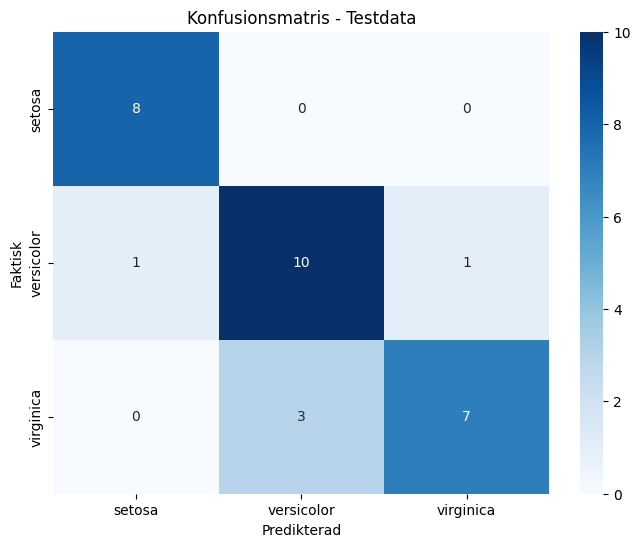

In [10]:
# Utvärdera på testdata
y_test_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n=== Testresultat för {best_model_name} ===")
print(f"Accuracy: {test_accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

# Konfusionsmatris
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Konfusionsmatris - Testdata')
plt.ylabel('Faktisk')
plt.xlabel('Predikterad')
plt.show()

### Steg 9: Visualisera beslutsgränser

c:\Users\daedi\.vscode\Categories\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


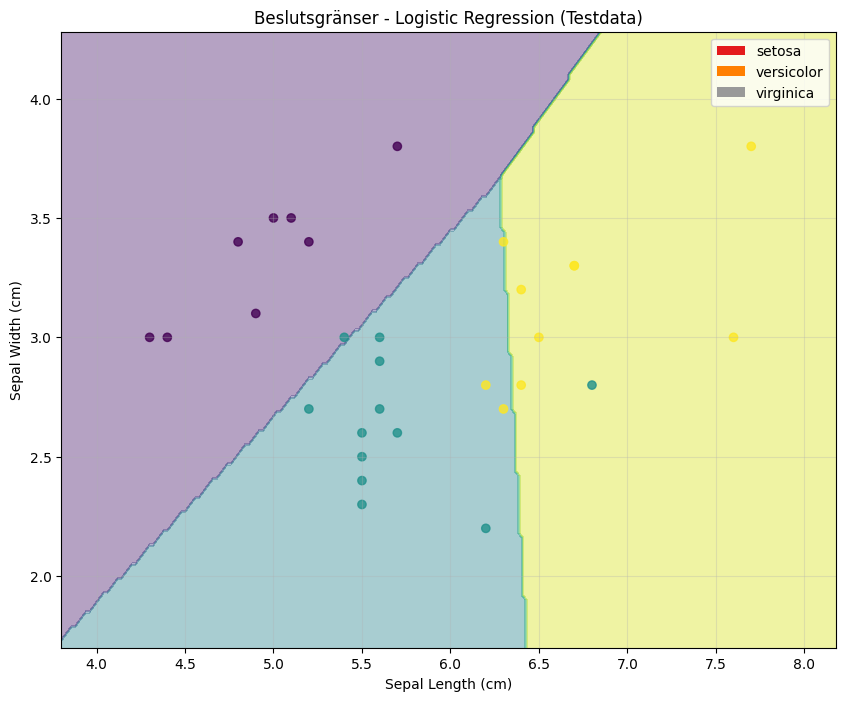

In [11]:
# Skapa meshgrid för visualisering av beslutsgränser
def plot_decision_boundary(pipeline, X, y, title):
    """
    Visualiserar beslutsgränser för en pipeline
    
    Parametrar:
    pipeline: Tränad sklearn pipeline
    X: Features (DataFrame med 2 kolumner)
    y: Target variabel
    title: Titel för plotten
    """
    # Skapa meshgrid
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Prediktera för varje punkt i meshgrid
    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plotta beslutsgränser
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    scatter = plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, alpha=0.8)
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.title(title)
    # Enkel legend-hantering
    # Skapa legend manuellt för att undvika ValueError
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=plt.cm.Set1(i/2), label=name) for i, name in enumerate(iris.target_names)]
    plt.legend(handles=legend_elements, loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualisera beslutsgränser för bästa modellen
plot_decision_boundary(best_pipeline, X_test, y_test, 
                      f'Beslutsgränser - {best_model_name} (Testdata)')

### Steg 10: Sammanfattning

In [12]:
print("=== SAMMANFATTNING ===")
print(f"\nDataset: Iris (150 samples, 2 features)")
print(f"Features: Sepal Length, Sepal Width")
print(f"Klasser: {list(iris.target_names)}")
print(f"\nBästa modell: {best_model_name}")
print(f"Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

print(f"\nModellens förmåga att klassificera iris-blommor:")
if test_accuracy > 0.9:
    print("• Utmärkt prestanda (>90%)")
elif test_accuracy > 0.8:
    print("• Bra prestanda (>80%)")
elif test_accuracy > 0.7:
    print("• Acceptabel prestanda (>70%)")
else:
    print("• Dålig prestanda (<70%)")

print(f"\nLärdomar:")
print("• Iris-setosa är lätt att separera från de andra klasserna")
print("• Versicolor och virginica överlappar delvis")
print("• Endast 2 features ger redan bra resultat")
print("• StandardScaler förbättrar prestandan för många modeller")
print("• Random Forest hanterar överlappande klasser bra")
print("• Vi har utökat den ursprungliga koden till ett komplett ML-flöde!")

=== SAMMANFATTNING ===

Dataset: Iris (150 samples, 2 features)
Features: Sepal Length, Sepal Width
Klasser: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Bästa modell: Logistic Regression
Test Accuracy: 0.833 (83.3%)

Modellens förmåga att klassificera iris-blommor:
• Bra prestanda (>80%)

Lärdomar:
• Iris-setosa är lätt att separera från de andra klasserna
• Versicolor och virginica överlappar delvis
• Endast 2 features ger redan bra resultat
• StandardScaler förbättrar prestandan för många modeller
• Random Forest hanterar överlappande klasser bra
• Vi har utökat den ursprungliga koden till ett komplett ML-flöde!
